# Import

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Data

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Fact

Which passenger class had the highest survival rate? 

1

In [5]:
df.groupby('Pclass')['Survived'].mean().nlargest(3)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

How large was the difference in survival rates between gender

0.742038 - 0.188908 = 0.55313

In [9]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Which age group (children, young adults, adults, elderly) had the highest survival rate? 

Children

In [10]:
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 25, 60, 120],
                         labels=['Children', 'Young Adults', 'Adults', 'Elderly'])

In [11]:
df.groupby('AgeGroup')['Survived'].mean()

C:\Users\14361\AppData\Local\Temp\ipykernel_36676\2140893742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Children        0.579710
Young Adults    0.362069
Adults          0.411765
Elderly         0.227273
Name: Survived, dtype: float64

Did family size affect survival probability? 

Yes

In [12]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [13]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

## Verification 

Is it true that passengers with higher fares were more likely to survive, or is this mainly because they belonged to first class? 

Both? Since class 1's s rate is higher and the price is higher as well

In [15]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

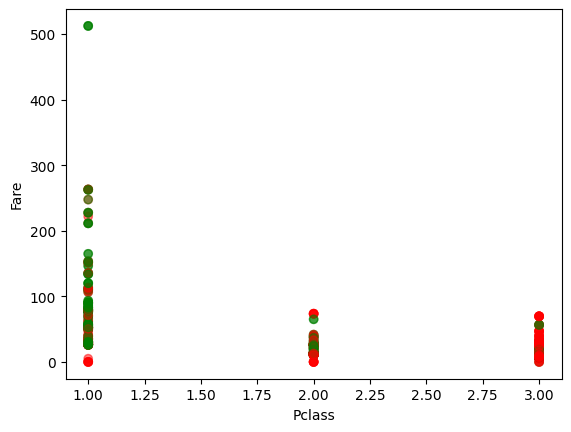

In [20]:
colors = df['Survived'].map({0: 'red', 1: 'green'})
plt.scatter(df['Pclass'], df['Fare'], c=colors, alpha=0.5)
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.show()

Did the “women survived more often” pattern hold across all passenger classes? 

Yes

In [23]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

Did age truly affect survival, or was the “children first” effect limited to specific groups? 

True

In [24]:
df.groupby(['AgeGroup', 'Pclass'])['Survived'].mean()

C:\Users\14361\AppData\Local\Temp\ipykernel_36676\24464183.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['AgeGroup', 'Pclass'])['Survived'].mean()


AgeGroup      Pclass
Children      1         0.750000
              2         1.000000
              3         0.416667
Young Adults  1         0.789474
              2         0.437500
              3         0.226027
Adults        1         0.661538
              2         0.419048
              3         0.198718
Elderly       1         0.214286
              2         0.333333
              3         0.200000
Name: Survived, dtype: float64

Were passengers traveling alone less likely to survive than those traveling with family members?

No, seems like it is a curve

In [25]:
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

## Exploratory

Which feature do you think was the most important for predicting survival, and why? 

Fare / Pclass

In [31]:
features = df[['Pclass', 'Sex', 'Age', 'FamilySize']].copy()
features['Sex'] = features['Sex'].map({'male': 0, 'female': 1})
features = features.fillna(features.median(numeric_only=True))

model = RandomForestClassifier(random_state=42)
model.fit(features, df['Survived'])

pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)

Age           0.391197
Sex           0.355708
Pclass        0.144836
FamilySize    0.108259
dtype: float64

In [29]:
df.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


In [ ]:
df[['Pclass', 'Fare']].corr()

,Pclass,Fare
Pclass,1.0000,-0.5495
Fare,-0.5495,1.0000


In [32]:
features = df[['Fare', 'Sex', 'Age', 'FamilySize']].copy()
features['Sex'] = features['Sex'].map({'male': 0, 'female': 1})
features = features.fillna(features.median(numeric_only=True))

model = RandomForestClassifier(random_state=42)
model.fit(features, df['Survived'])

pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)

Fare          0.357226
Sex           0.278442
Age           0.265653
FamilySize    0.098679
dtype: float64

Did the Titanic dataset contain sampling bias? 

Yes, e.g., the numbers of adult and young adult are far more larger than others

In [45]:
features = df[['Pclass', 'Sex', 'AgeGroup', 'FamilySize']].copy()
features['Sex'] = features['Sex'].map({'male': 0, 'female': 1})
features = features.fillna(features.median(numeric_only=True))
for col in features:
    print(df.groupby([col]).size(), '\n')

Pclass
1    216
2    184
3    491
dtype: int64 

Sex
female    314
male      577
dtype: int64 

AgeGroup
Children         69
Young Adults    232
Adults          391
Elderly          22
dtype: int64 

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
dtype: int64 



C:\Users\14361\AppData\Local\Temp\ipykernel_36676\4027571879.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby([col]).size(), '\n')


Did converting FamilySize into an IsAlone feature improve model performance?

Not much different

In [46]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [47]:
df.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [49]:
features = df[['Pclass', 'Sex', 'Age', 'FamilySize', 'Fare']].copy()
features['Sex'] = features['Sex'].map({'male': 0, 'female': 1})
features = features.fillna(features.median(numeric_only=True))

split = int(len(df) * 0.8)
X_train, X_test = features.iloc[:split], features.iloc[split:]
y_train, y_test = df['Survived'].iloc[:split], df['Survived'].iloc[split:]

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, preds))

Accuracy: 0.8379888268156425


In [50]:
features = df[['Pclass', 'Sex', 'Age', 'IsAlone', 'Fare']].copy()
features['Sex'] = features['Sex'].map({'male': 0, 'female': 1})
features = features.fillna(features.median(numeric_only=True))

split = int(len(df) * 0.8)
X_train, X_test = features.iloc[:split], features.iloc[split:]
y_train, y_test = df['Survived'].iloc[:split], df['Survived'].iloc[split:]

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, preds))

Accuracy: 0.8324022346368715
